In [4]:
# =========================
# Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Load Dataset
# =========================
df = pd.read_csv("Fact_Patient_LTV.csv")

# =========================
# Basic Information
# =========================
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (20000, 27)

Columns:
Index(['Fact_ID', 'Patient_Key', 'Patient_ID', 'Patient_Name', 'Age', 'Gender',
       'Location_Key', 'City', 'Area', 'Department_Key', 'Department',
       'Date_Key', 'Status_Key', 'First_Visit_Date', 'Last_Visit_Date',
       'Churn_Flag', 'Returning_Patient', 'Visit_Frequency',
       'Avg_Bill_Amount_INR', 'Lifetime_Value_INR', 'Patient_Status',
       'Risk_Level', 'Followup_Required', 'Appointment_Count', 'No_Show_Count',
       'Last_Visit_Gap_Days', 'Total_Billing'],
      dtype='object')

Data Types:
Fact_ID                  int64
Patient_Key              int64
Patient_ID              object
Patient_Name            object
Age                      int64
Gender                  object
Location_Key             int64
City                    object
Area                    object
Department_Key           int64
Department              object
Date_Key                 int64
Status_Key               int64
First_Visit_Date        object
Last_Visit_Date     

In [2]:
# =========================
# Statistical Summary
# =========================
print("\nNumerical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))


Numerical Summary
            Fact_ID   Patient_Key           Age  Location_Key  Department_Key  \
count  20000.000000  20000.000000  20000.000000  20000.000000    20000.000000   
mean   10000.500000  10000.500000     45.994950     50.549950        4.004500   
std     5773.647028   5773.647028     22.311137     28.926138        2.000195   
min        1.000000      1.000000      1.000000      1.000000        1.000000   
25%     5000.750000   5000.750000     29.000000     26.000000        2.000000   
50%    10000.500000  10000.500000     48.000000     51.000000        4.000000   
75%    15000.250000  15000.250000     65.000000     75.000000        6.000000   
max    20000.000000  20000.000000     84.000000    100.000000        7.000000   

           Date_Key    Status_Key    Churn_Flag  Returning_Patient  \
count  20000.000000  20000.000000  20000.000000       20000.000000   
mean     545.168600      4.444300      0.091550           0.584750   
std      315.392142      3.056577      0.

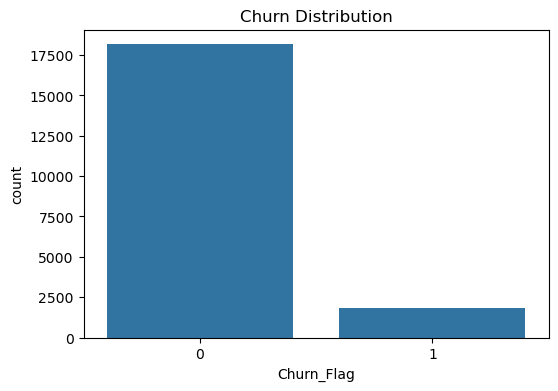

Churn_Flag
0    18169
1     1831
Name: count, dtype: int64
Churn_Flag
0    90.845
1     9.155
Name: proportion, dtype: float64


In [3]:
# =========================
# Target Variable Analysis
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='Churn_Flag', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Churn_Flag'].value_counts())
print(df['Churn_Flag'].value_counts(normalize=True)*100)

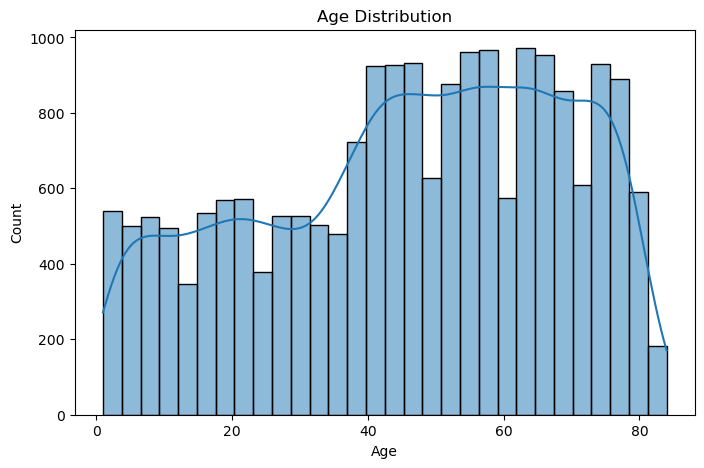

In [4]:
# =========================
# Age Distribution
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

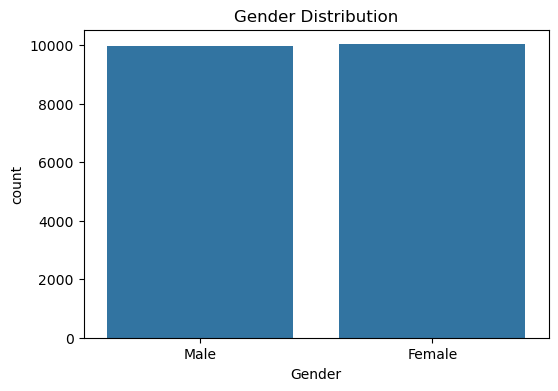

In [5]:
# =========================
# Gender Distribution
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

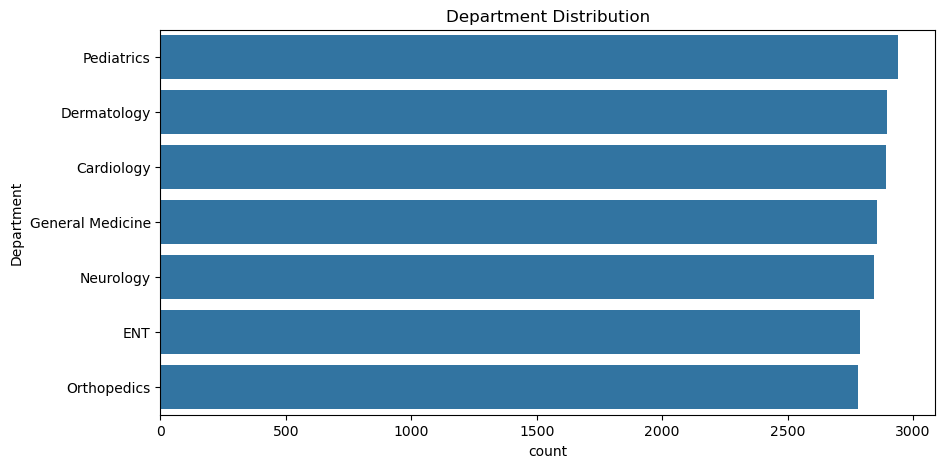

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='Department',
    data=df,
    order=df['Department'].value_counts().index
)
plt.title("Department Distribution")
plt.show()

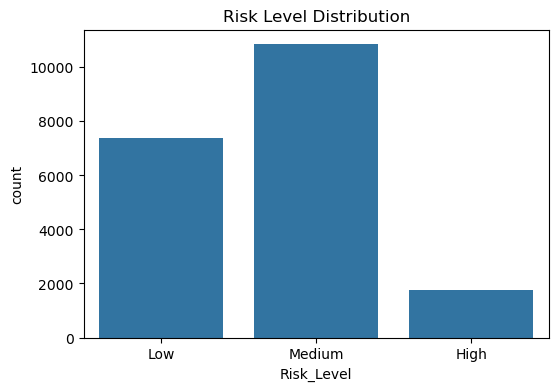

In [7]:
# =========================
# Risk Level Distribution
# =========================
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Level', data=df)
plt.title("Risk Level Distribution")
plt.show()

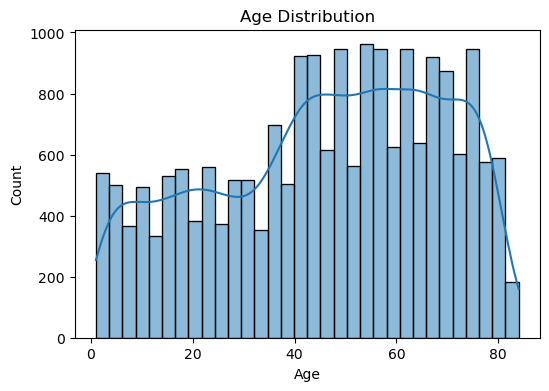

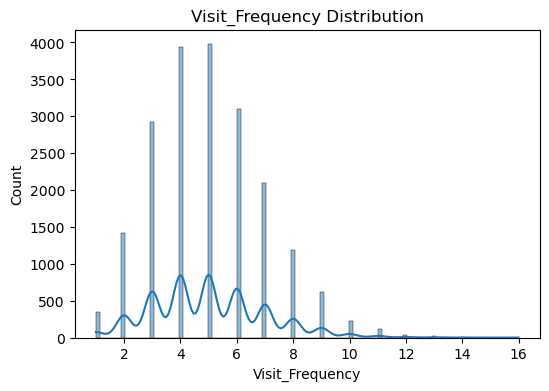

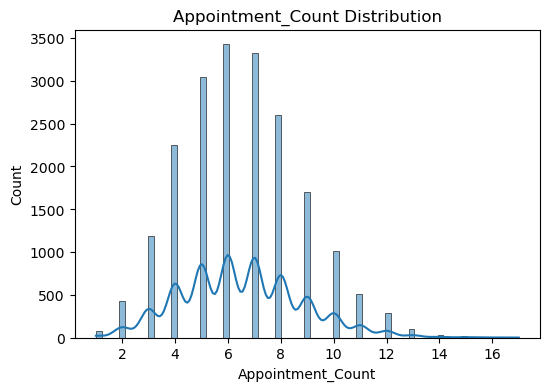

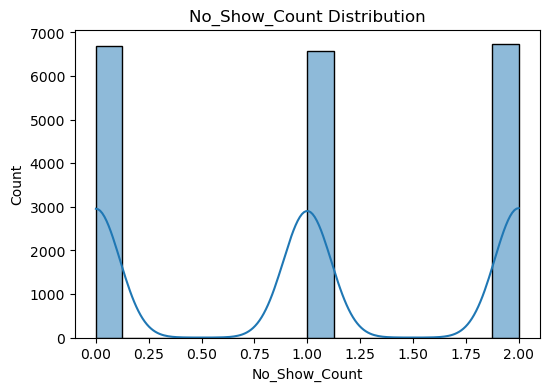

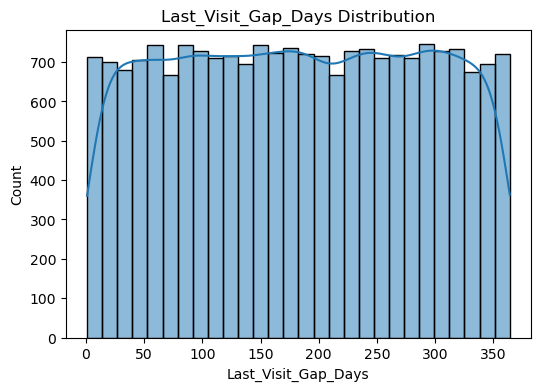

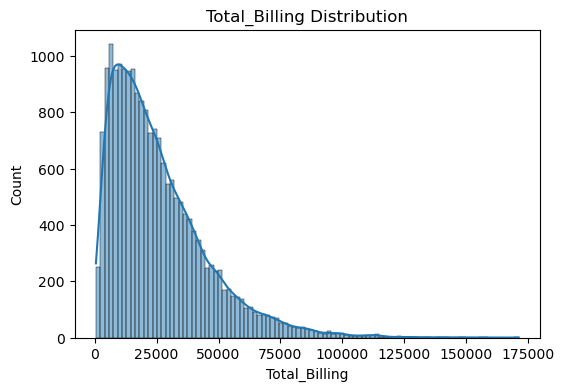

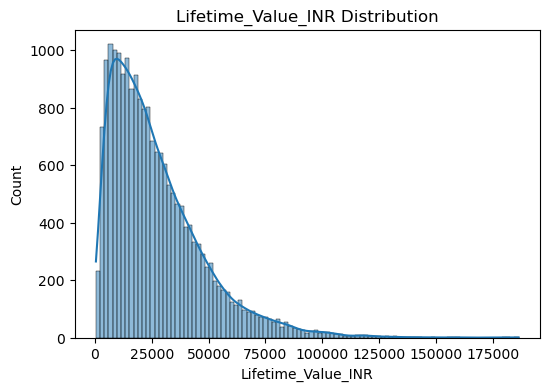

In [8]:
# =========================
# Numerical Features
# =========================
num_cols = [
    'Age',
    'Visit_Frequency',
    'Appointment_Count',
    'No_Show_Count',
    'Last_Visit_Gap_Days',
    'Total_Billing',
    'Lifetime_Value_INR'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

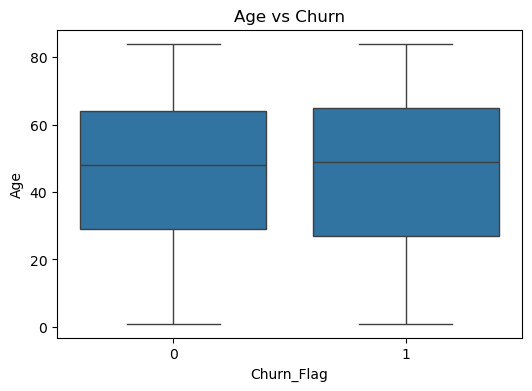

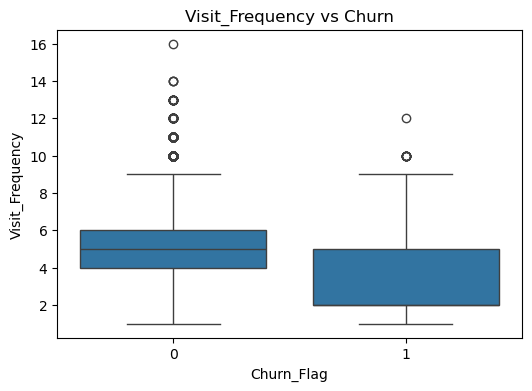

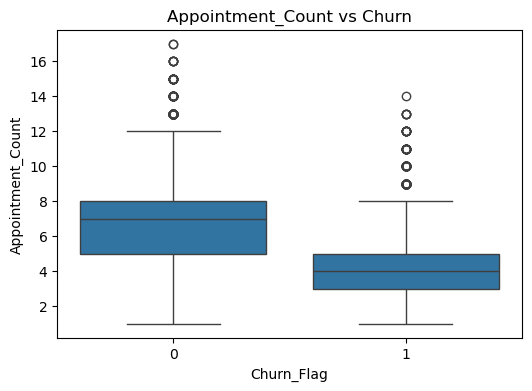

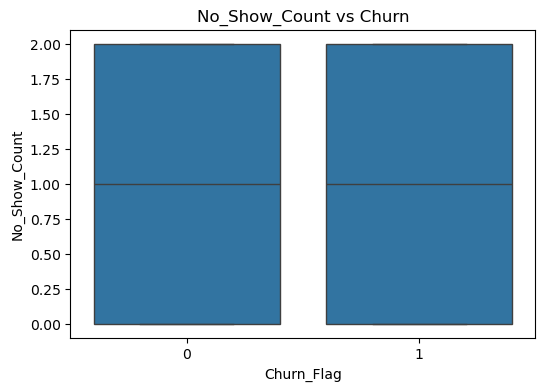

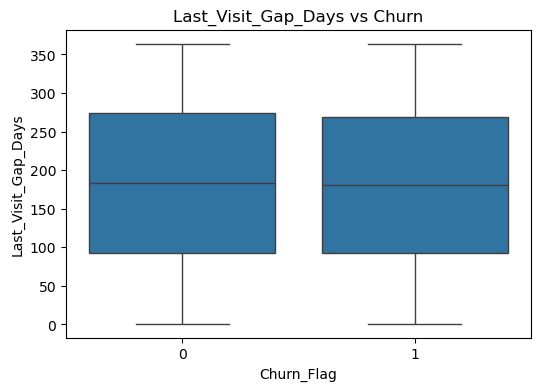

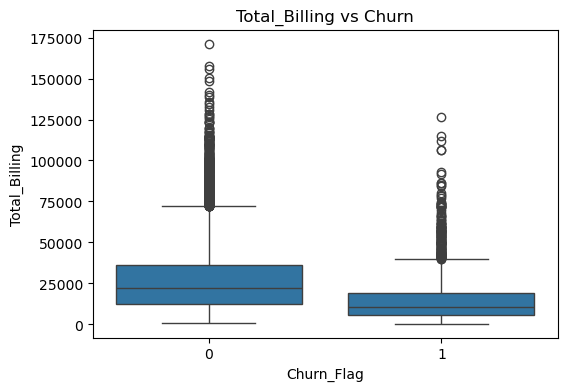

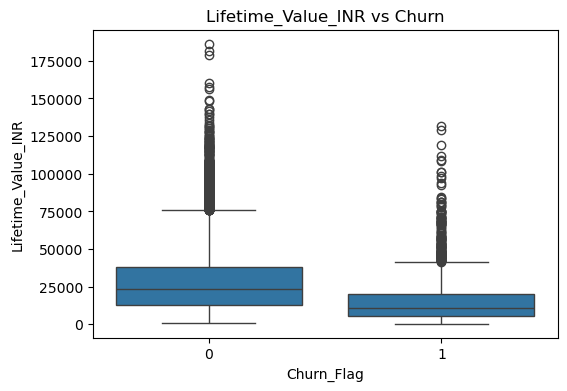

In [9]:
# =========================
# Boxplots vs Churn
# =========================
important_num = [
    'Age',
    'Visit_Frequency',
    'Appointment_Count',
    'No_Show_Count',
    'Last_Visit_Gap_Days',
    'Total_Billing',
    'Lifetime_Value_INR'
]

for col in important_num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn_Flag', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

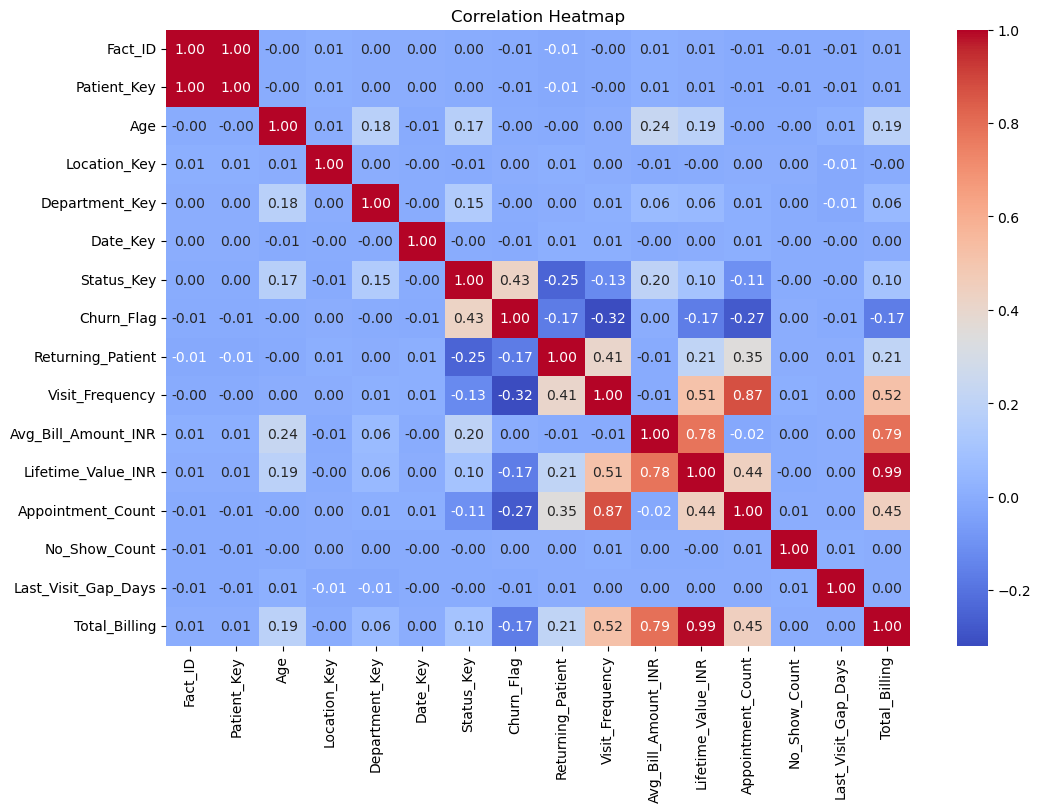

In [10]:
# =========================
# Correlation Heatmap
# =========================
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

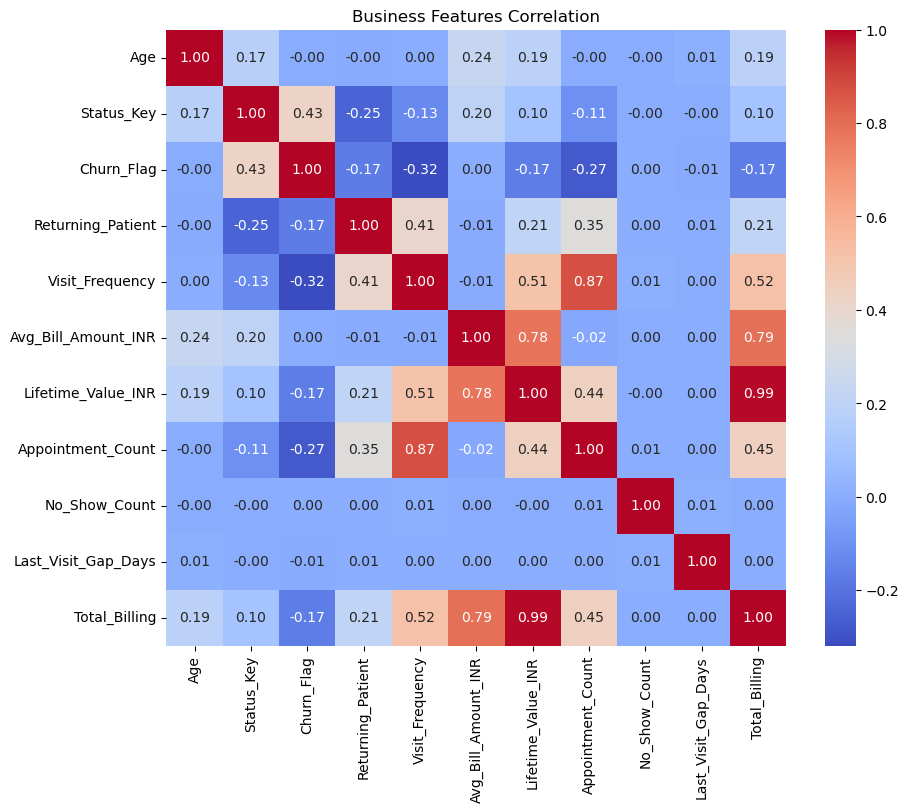

In [11]:
corr_cols = [
    'Age',
    'Status_Key',
    'Churn_Flag',
    'Returning_Patient',
    'Visit_Frequency',
    'Avg_Bill_Amount_INR',
    'Lifetime_Value_INR',
    'Appointment_Count',
    'No_Show_Count',
    'Last_Visit_Gap_Days',
    'Total_Billing'
]

plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Business Features Correlation")
plt.show()

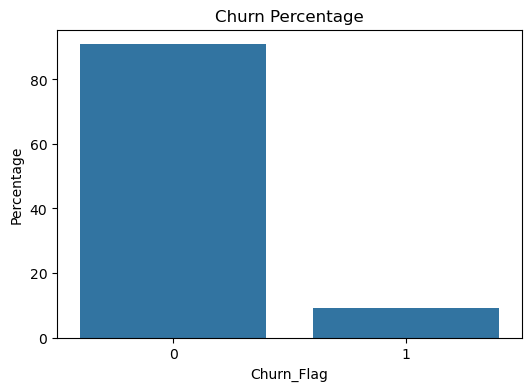

In [12]:
churn_pct = df['Churn_Flag'].value_counts(normalize=True)*100

plt.figure(figsize=(6,4))
sns.barplot(
    x=churn_pct.index,
    y=churn_pct.values
)
plt.title("Churn Percentage")
plt.ylabel("Percentage")
plt.show()

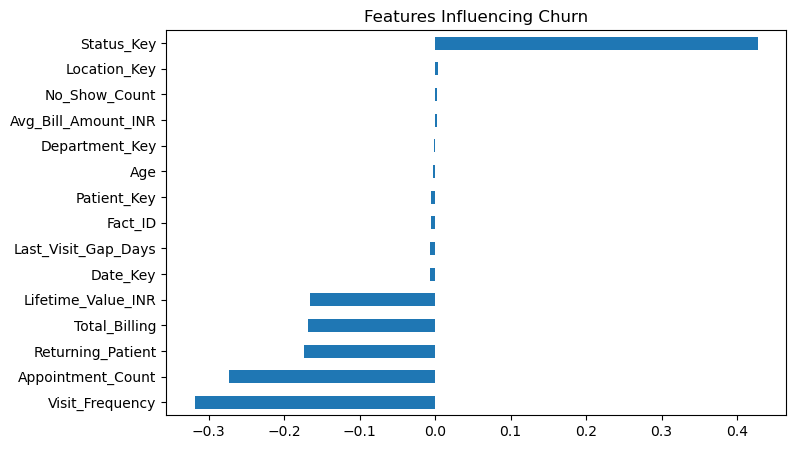

In [13]:
corr = df.select_dtypes(include='number').corr()['Churn_Flag']

corr.drop('Churn_Flag').sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Features Influencing Churn")
plt.show()

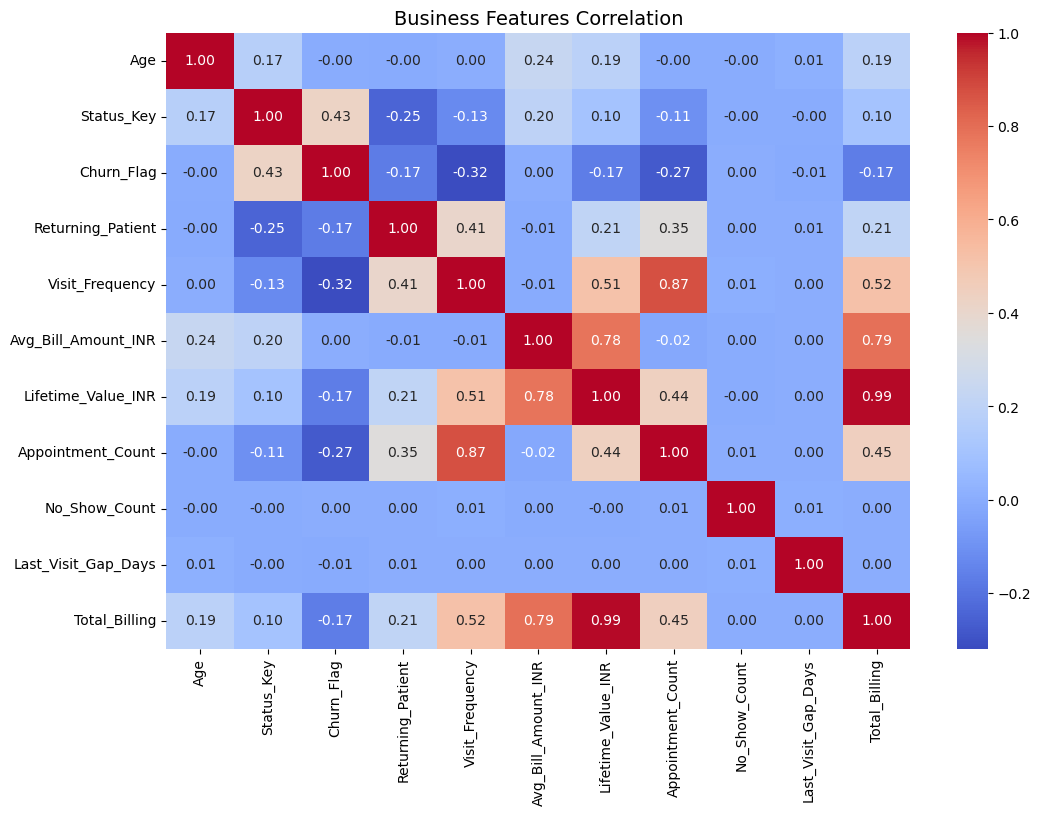

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Business Features Correlation", fontsize=14)
plt.show()

In [15]:
df.groupby('Status_Key')['Churn_Flag'].agg(['count','mean'])

,count,mean
Status_Key,,
1,4062,0.0
2,3954,0.0
3,1408,0.0
4,484,0.0
5,3532,0.0
6,1632,0.0
7,1254,1.0
8,1027,0.0
9,1681,0.0


In [16]:
df.groupby('Patient_Status')['Churn_Flag'].agg(['count','mean'])

,count,mean
Patient_Status,,
Active Patient,18169,0.0
Churned Patient,1831,1.0


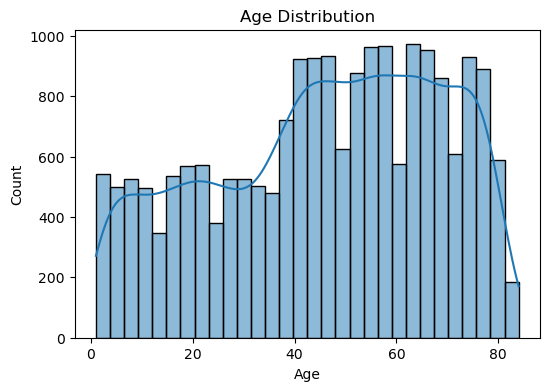

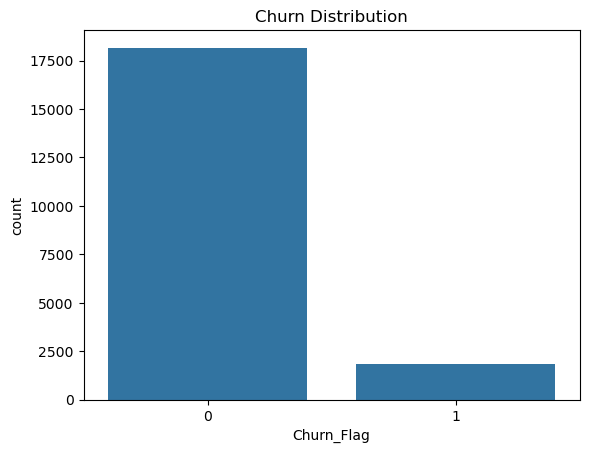

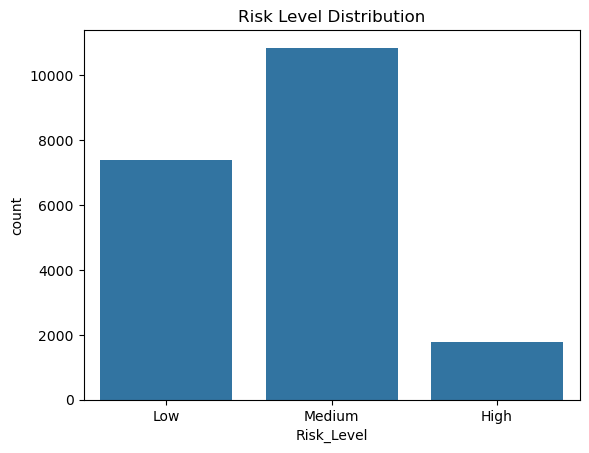

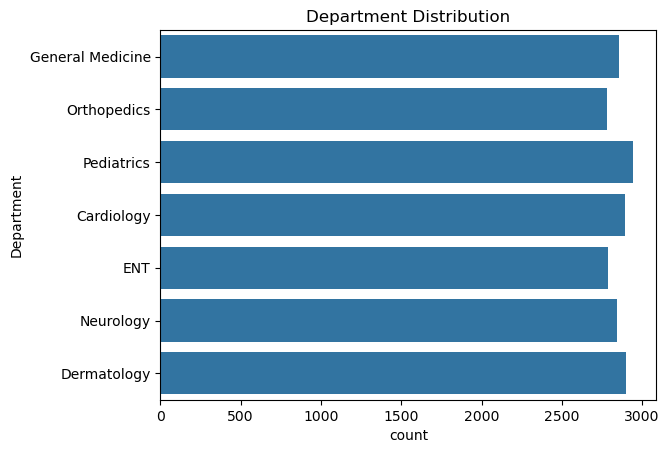

In [17]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Churn Distribution
sns.countplot(x='Churn_Flag', data=df)
plt.title("Churn Distribution")
plt.show()

# Risk Level Distribution
sns.countplot(x='Risk_Level', data=df)
plt.title("Risk Level Distribution")
plt.show()

# Department Distribution
sns.countplot(y='Department', data=df)
plt.title("Department Distribution")
plt.show()

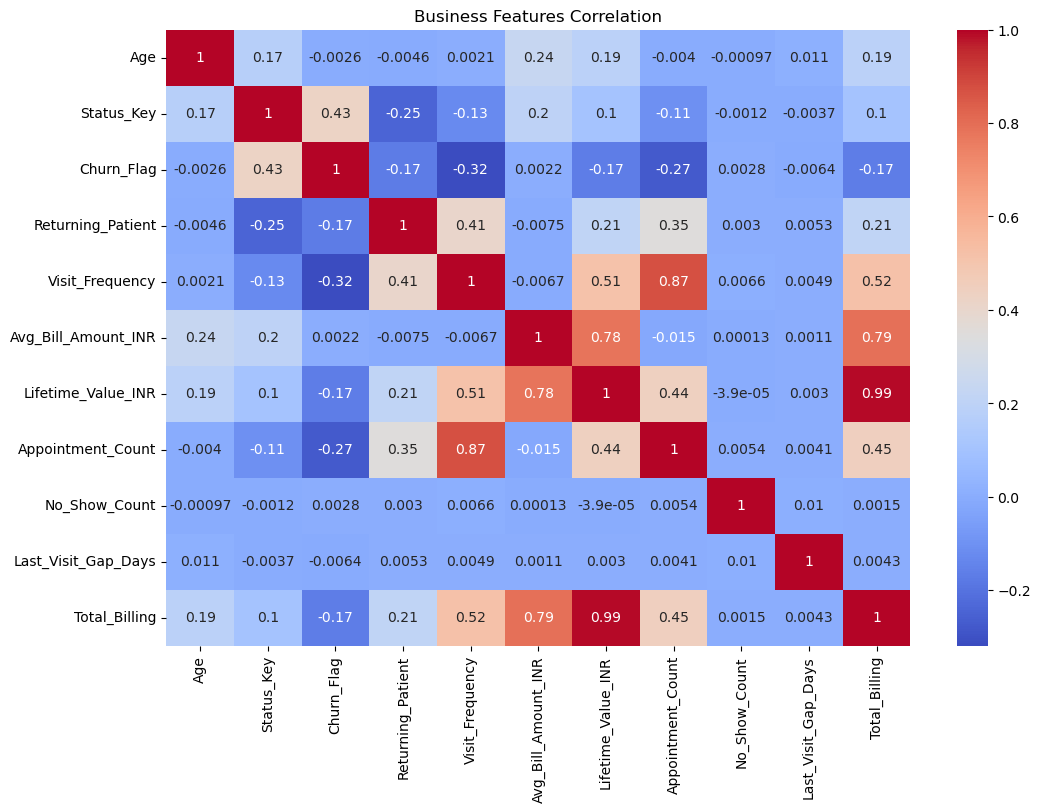

In [18]:
corr_cols = [
    'Age',
    'Status_Key',
    'Churn_Flag',
    'Returning_Patient',
    'Visit_Frequency',
    'Avg_Bill_Amount_INR',
    'Lifetime_Value_INR',
    'Appointment_Count',
    'No_Show_Count',
    'Last_Visit_Gap_Days',
    'Total_Billing'
]

plt.figure(figsize=(12,8))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Business Features Correlation")
plt.show()

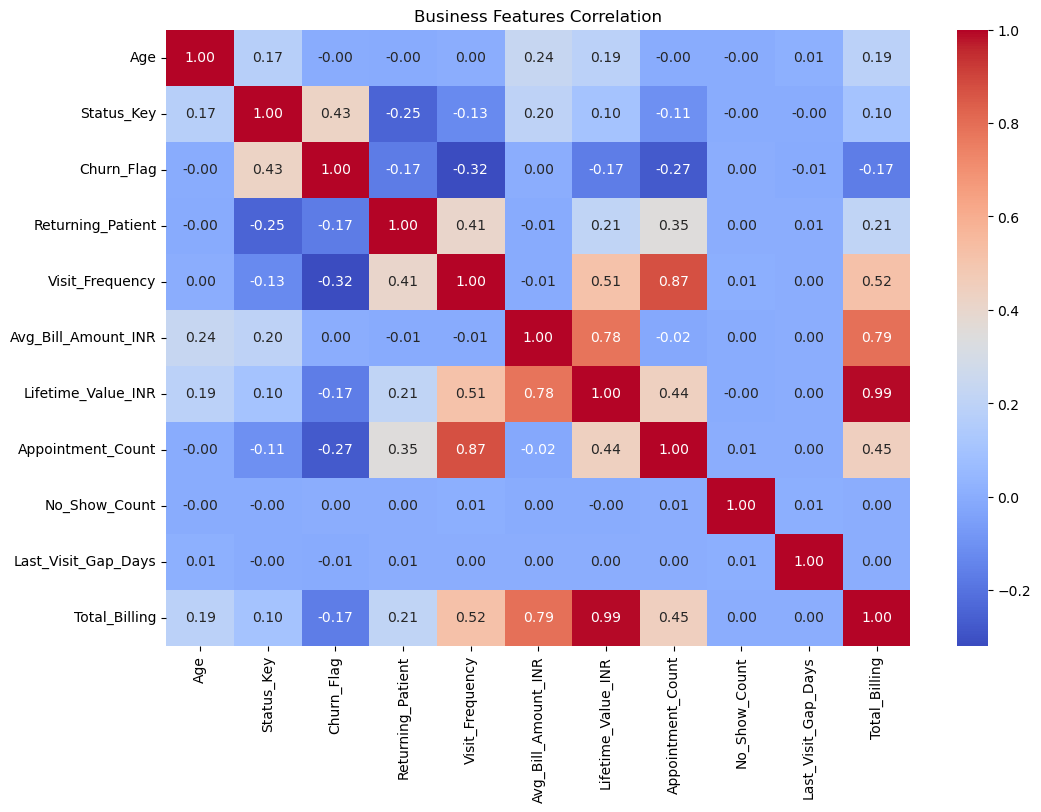

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt='.2f',     # <-- add this
    cmap='coolwarm'
)

plt.title("Business Features Correlation")
plt.show()

Shape: (15, 6)

Columns:
Index(['Status_Key', 'Patient_Status', 'Churn_Flag', 'Returning_Patient',
       'Risk_Level', 'Followup_Required'],
      dtype='object')

Missing Values:
Status_Key           0
Patient_Status       0
Churn_Flag           0
Returning_Patient    0
Risk_Level           0
Followup_Required    0
dtype: int64

Duplicate Rows:
0


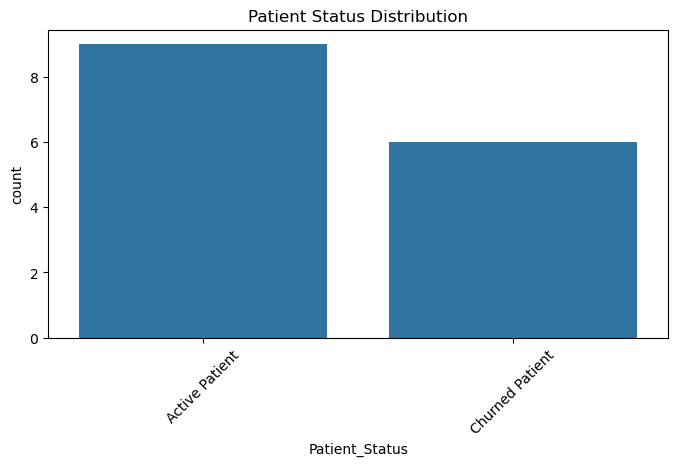

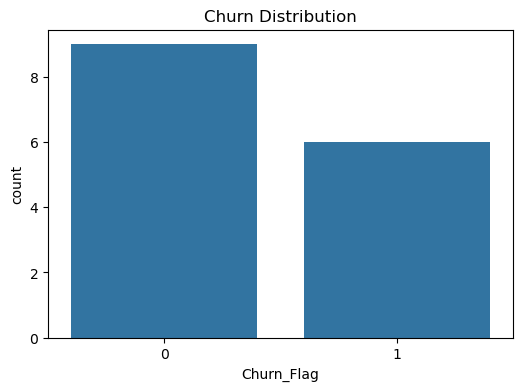

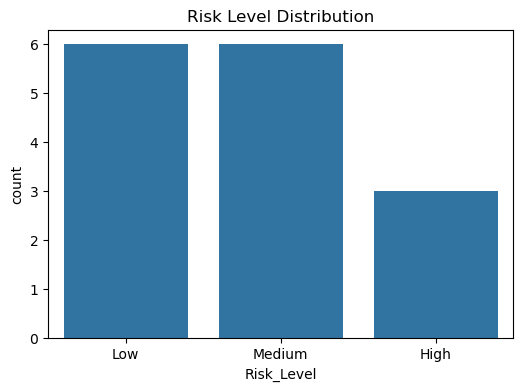

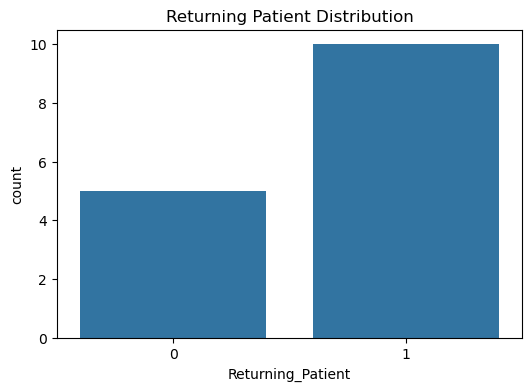

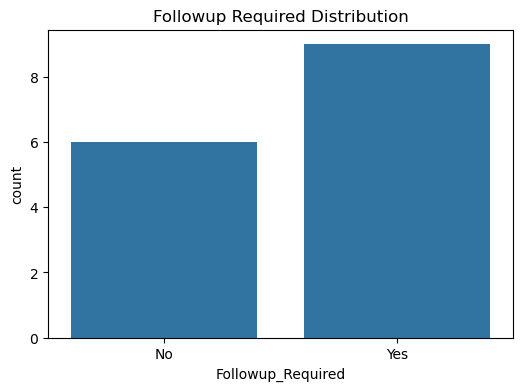

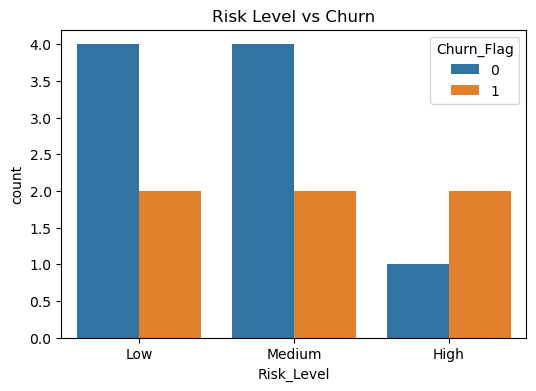

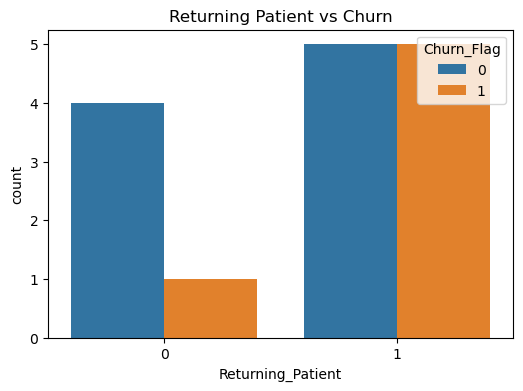

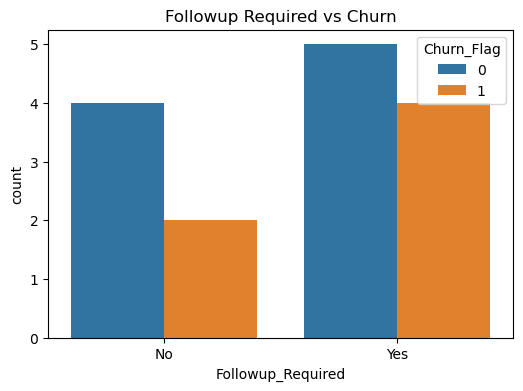

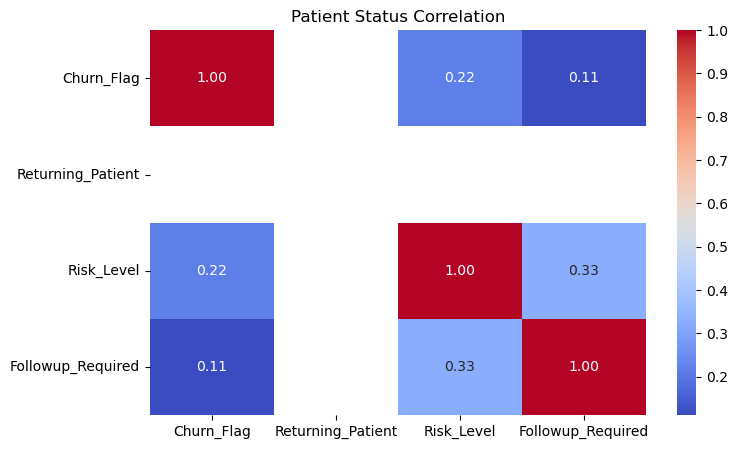

In [20]:
# =========================
# Import Libraries
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Load Dataset
# =========================
df = pd.read_csv("Dim_Patient_Status.csv")

# =========================
# Basic Information
# =========================
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# =========================
# Univariate Analysis
# =========================

# Patient Status Distribution
plt.figure(figsize=(8,4))
sns.countplot(x='Patient_Status', data=df)
plt.title("Patient Status Distribution")
plt.xticks(rotation=45)
plt.show()

# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn_Flag', data=df)
plt.title("Churn Distribution")
plt.show()

# Risk Level Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Level', data=df)
plt.title("Risk Level Distribution")
plt.show()

# Returning Patient Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Returning_Patient', data=df)
plt.title("Returning Patient Distribution")
plt.show()

# Followup Required Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Followup_Required', data=df)
plt.title("Followup Required Distribution")
plt.show()

# =========================
# Bivariate Analysis
# =========================

# Risk Level vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Level',
              hue='Churn_Flag',
              data=df)
plt.title("Risk Level vs Churn")
plt.show()

# Returning Patient vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Returning_Patient',
              hue='Churn_Flag',
              data=df)
plt.title("Returning Patient vs Churn")
plt.show()

# Followup Required vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Followup_Required',
              hue='Churn_Flag',
              data=df)
plt.title("Followup Required vs Churn")
plt.show()

# =========================
# Multivariate Analysis
# =========================

df_corr = df.copy()

df_corr['Returning_Patient'] = df_corr['Returning_Patient'].map({'Yes':1,'No':0})
df_corr['Followup_Required'] = df_corr['Followup_Required'].map({'Yes':1,'No':0})
df_corr['Risk_Level'] = df_corr['Risk_Level'].map({'Low':1,'Medium':2,'High':3})

plt.figure(figsize=(8,5))
sns.heatmap(
    df_corr[['Churn_Flag',
             'Returning_Patient',
             'Risk_Level',
             'Followup_Required']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Patient Status Correlation")
plt.show()

(100, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Location_Key  100 non-null    int64 
 1   City          100 non-null    object
 2   Area          100 non-null    object
 3   State         100 non-null    object
 4   Pincode       100 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.0+ KB
None
Location_Key    0
City            0
Area            0
State           0
Pincode         0
dtype: int64


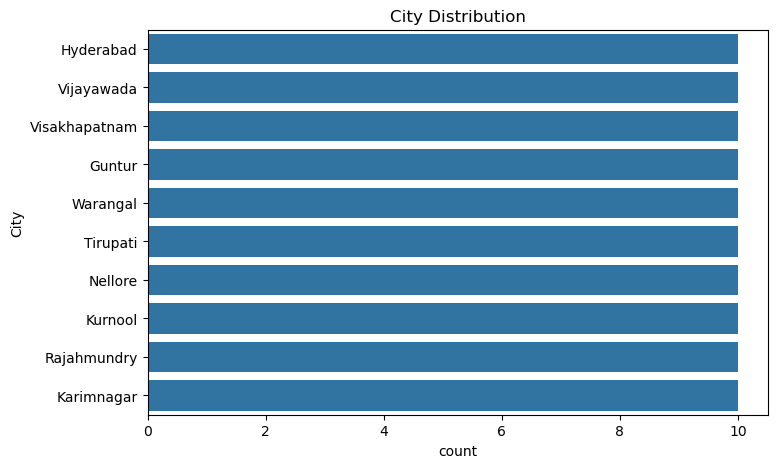

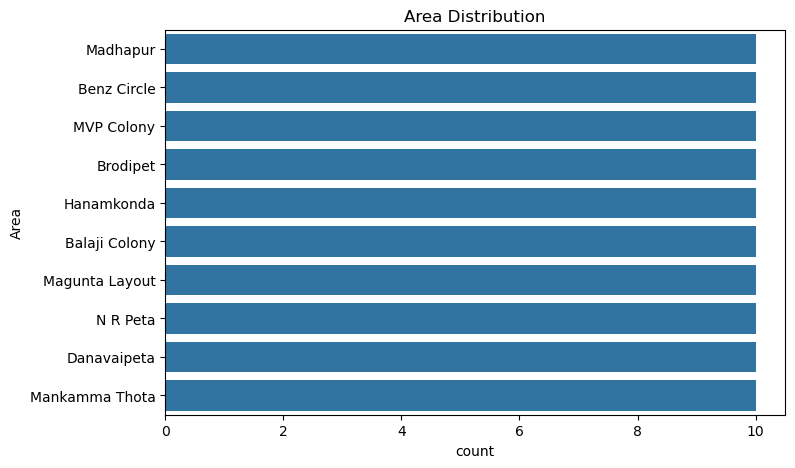


City Counts
City
Hyderabad        10
Vijayawada       10
Visakhapatnam    10
Guntur           10
Warangal         10
Tirupati         10
Nellore          10
Kurnool          10
Rajahmundry      10
Karimnagar       10
Name: count, dtype: int64

Area Counts
Area
Madhapur          10
Benz Circle       10
MVP Colony        10
Brodipet          10
Hanamkonda        10
Balaji Colony     10
Magunta Layout    10
N R Peta          10
Danavaipeta       10
Mankamma Thota    10
Name: count, dtype: int64


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Dim_Location.csv")

# Basic Info
print(df.shape)
print(df.info())
print(df.isnull().sum())

# =====================
# City Distribution
# =====================
plt.figure(figsize=(8,5))
sns.countplot(
    y='City',
    data=df,
    order=df['City'].value_counts().index
)
plt.title("City Distribution")
plt.show()

# =====================
# Area Distribution
# =====================
plt.figure(figsize=(8,5))
sns.countplot(
    y='Area',
    data=df,
    order=df['Area'].value_counts().index
)
plt.title("Area Distribution")
plt.show()

# =====================
# Frequency Tables
# =====================
print("\nCity Counts")
print(df['City'].value_counts())

print("\nArea Counts")
print(df['Area'].value_counts())

Shape: (1095, 8)

Columns:
Index(['Date_Key', 'Full_Date', 'Day_Name', 'Month', 'Month_Number', 'Quarter',
       'Year', 'Weekday_Weekend'],
      dtype='object')

Missing Values:
Date_Key           0
Full_Date          0
Day_Name           0
Month              0
Month_Number       0
Quarter            0
Year               0
Weekday_Weekend    0
dtype: int64

Unique Values:
Date_Key           1095
Full_Date          1095
Day_Name              7
Month                12
Month_Number         12
Quarter               4
Year                  4
Weekday_Weekend       2
dtype: int64


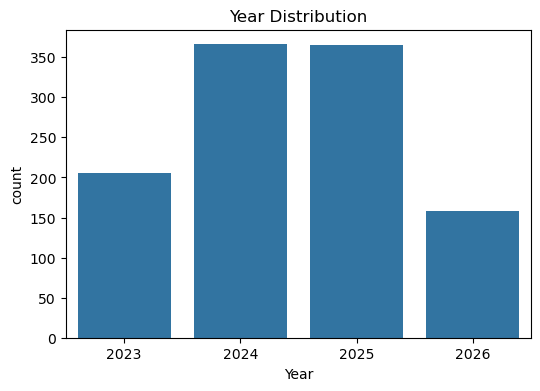

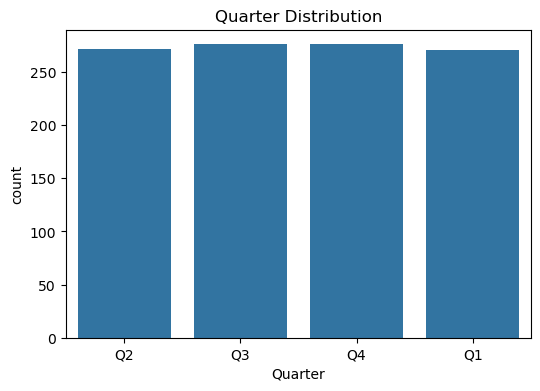

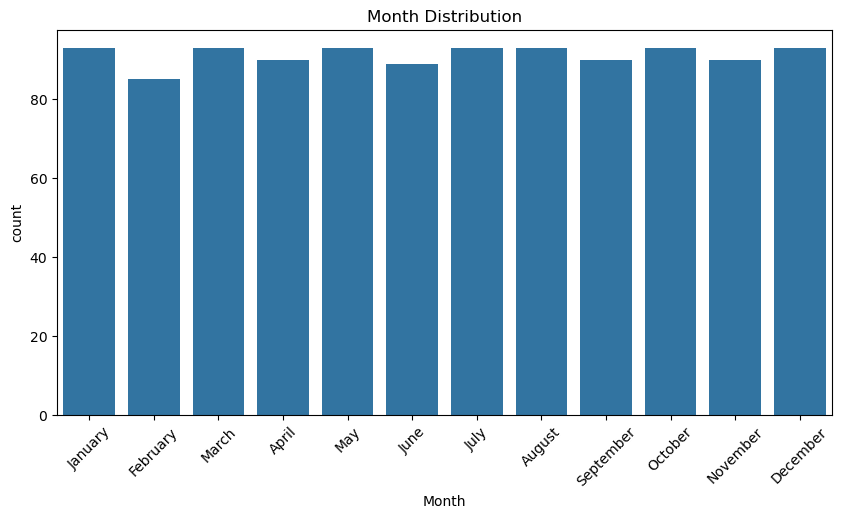

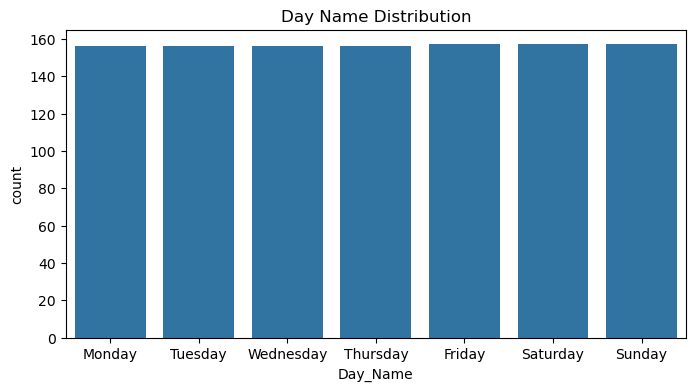

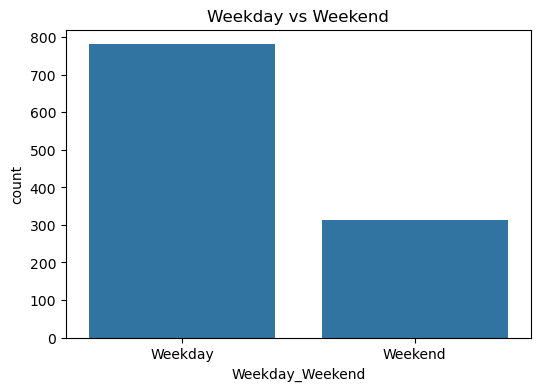


Year Counts
Year
2023    206
2024    366
2025    365
2026    158
Name: count, dtype: int64

Quarter Counts
Quarter
Q3    276
Q4    276
Q2    272
Q1    271
Name: count, dtype: int64

Weekday/Weekend Counts
Weekday_Weekend
Weekday    781
Weekend    314
Name: count, dtype: int64


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Dim_Date.csv")

# Basic Information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Values:")
print(df.nunique())

# =====================
# Year Distribution
# =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Year', data=df)
plt.title("Year Distribution")
plt.show()

# =====================
# Quarter Distribution
# =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Quarter', data=df)
plt.title("Quarter Distribution")
plt.show()

# =====================
# Month Distribution
# =====================
plt.figure(figsize=(10,5))
sns.countplot(
    x='Month',
    data=df,
    order=['January','February','March','April',
           'May','June','July','August',
           'September','October','November','December']
)
plt.xticks(rotation=45)
plt.title("Month Distribution")
plt.show()

# =====================
# Day Name Distribution
# =====================
plt.figure(figsize=(8,4))
sns.countplot(
    x='Day_Name',
    data=df,
    order=['Monday','Tuesday','Wednesday',
           'Thursday','Friday','Saturday','Sunday']
)
plt.title("Day Name Distribution")
plt.show()

# =====================
# Weekday vs Weekend
# =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Weekday_Weekend', data=df)
plt.title("Weekday vs Weekend")
plt.show()

# Frequency Tables
print("\nYear Counts")
print(df['Year'].value_counts().sort_index())

print("\nQuarter Counts")
print(df['Quarter'].value_counts())

print("\nWeekday/Weekend Counts")
print(df['Weekday_Weekend'].value_counts())

Shape: (7, 6)

Columns:
Index(['Department_Key', 'Department', 'Department_Category',
       'Consultation_Type', 'Avg_Consultation_Fee', 'Criticality_Level'],
      dtype='object')

Missing Values:
Department_Key          0
Department              0
Department_Category     0
Consultation_Type       0
Avg_Consultation_Fee    0
Criticality_Level       0
dtype: int64


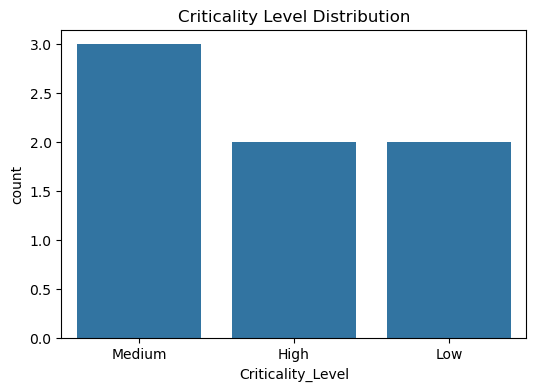

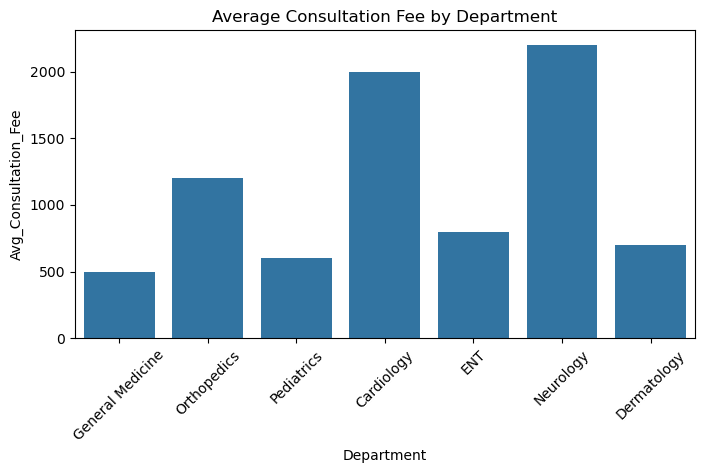

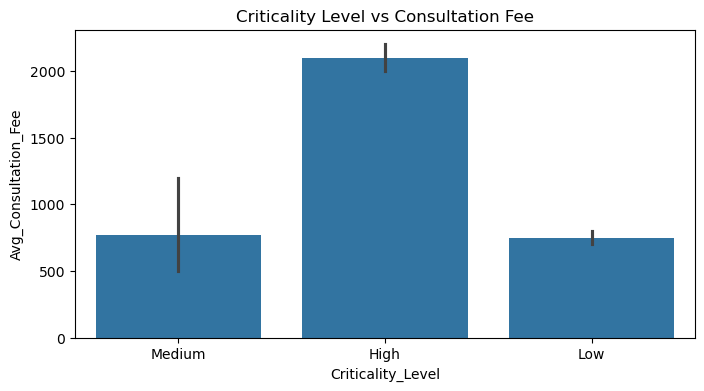

         Department  Avg_Consultation_Fee Criticality_Level
0  General Medicine                   500            Medium
1       Orthopedics                  1200            Medium
2        Pediatrics                   600            Medium
3        Cardiology                  2000              High
4               ENT                   800               Low
5         Neurology                  2200              High
6       Dermatology                   700               Low


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Dim_Department.csv")

# Basic Info
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

# =====================
# Criticality Level
# =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Criticality_Level', data=df)
plt.title("Criticality Level Distribution")
plt.show()

# =====================
# Consultation Fee
# =====================
plt.figure(figsize=(8,4))
sns.barplot(
    x='Department',
    y='Avg_Consultation_Fee',
    data=df
)
plt.xticks(rotation=45)
plt.title("Average Consultation Fee by Department")
plt.show()

# =====================
# Criticality vs Fee
# =====================
plt.figure(figsize=(8,4))
sns.barplot(
    x='Criticality_Level',
    y='Avg_Consultation_Fee',
    data=df
)
plt.title("Criticality Level vs Consultation Fee")
plt.show()

# Summary Table
print(df[['Department',
          'Avg_Consultation_Fee',
          'Criticality_Level']])

Shape: (20000, 8)

Columns:
Index(['Patient_Key', 'Patient_ID', 'Patient_Name', 'Age', 'Gender',
       'Age_Group', 'Blood_Group', 'Insurance_Type'],
      dtype='object')

Missing Values:
Patient_Key       0
Patient_ID        0
Patient_Name      0
Age               0
Gender            0
Age_Group         0
Blood_Group       0
Insurance_Type    0
dtype: int64

Unique Values:
Patient_Key       20000
Patient_ID        20000
Patient_Name      19295
Age                  84
Gender                2
Age_Group             4
Blood_Group           8
Insurance_Type        4
dtype: int64


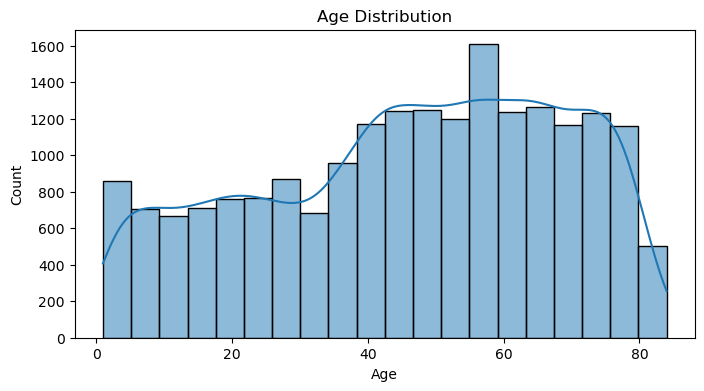

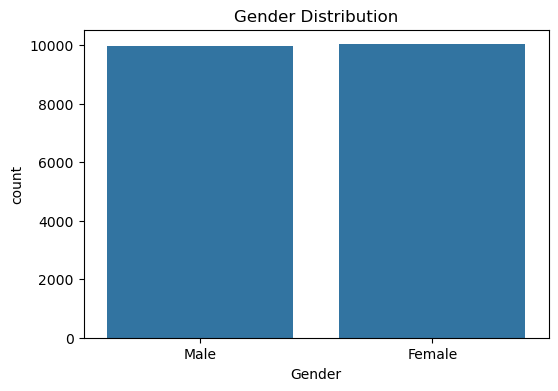

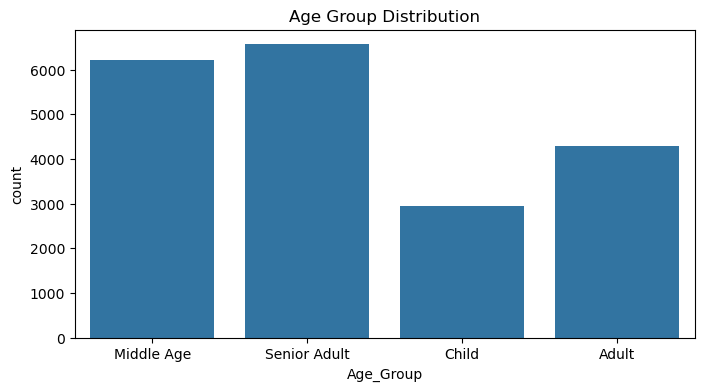

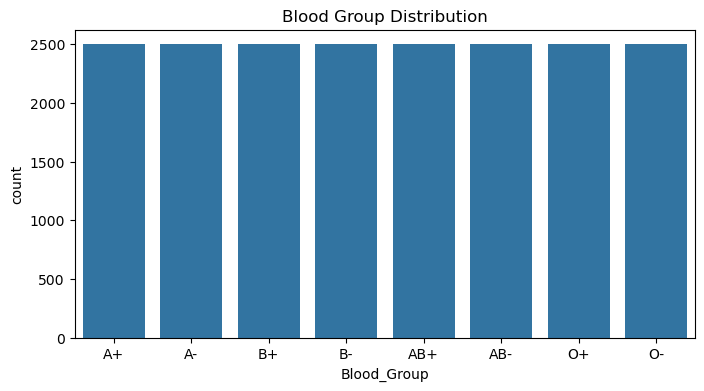

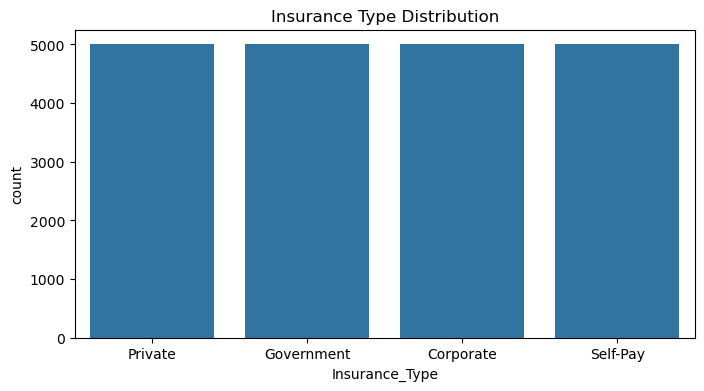

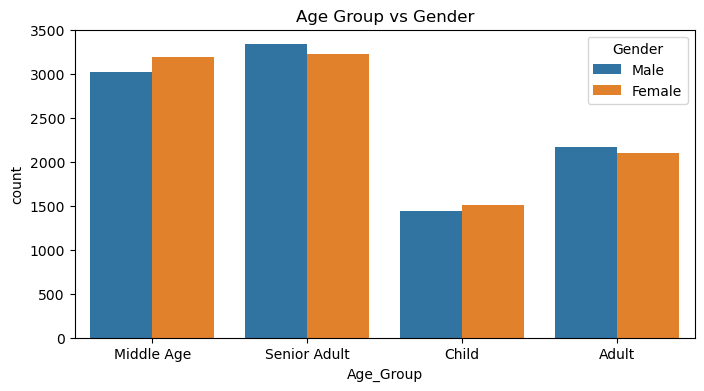

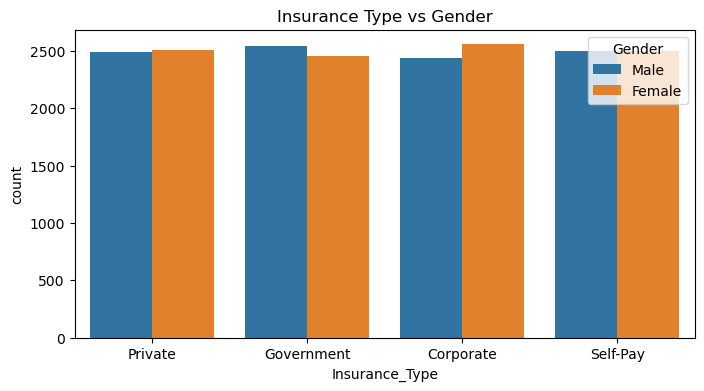

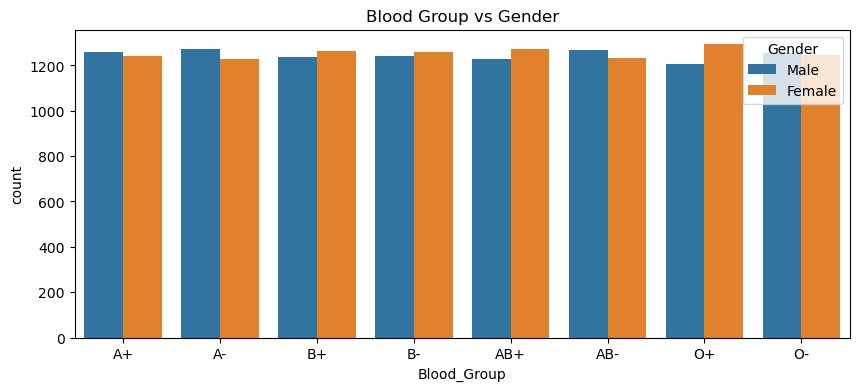

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Dim_Patient.csv")

# Basic Information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Values:")
print(df.nunique())

# =====================
# Age Distribution
# =====================
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# =====================
# Gender Distribution
# =====================
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# =====================
# Age Group Distribution
# =====================
plt.figure(figsize=(8,4))
sns.countplot(x='Age_Group', data=df)
plt.title("Age Group Distribution")
plt.show()

# =====================
# Blood Group Distribution
# =====================
plt.figure(figsize=(8,4))
sns.countplot(x='Blood_Group', data=df)
plt.title("Blood Group Distribution")
plt.show()

# =====================
# Insurance Type Distribution
# =====================
plt.figure(figsize=(8,4))
sns.countplot(x='Insurance_Type', data=df)
plt.title("Insurance Type Distribution")
plt.show()

# =====================
# Bivariate Analysis
# =====================

# Gender vs Age Group
plt.figure(figsize=(8,4))
sns.countplot(x='Age_Group', hue='Gender', data=df)
plt.title("Age Group vs Gender")
plt.show()

# Insurance Type vs Gender
plt.figure(figsize=(8,4))
sns.countplot(x='Insurance_Type', hue='Gender', data=df)
plt.title("Insurance Type vs Gender")
plt.show()

# Blood Group vs Gender
plt.figure(figsize=(10,4))
sns.countplot(x='Blood_Group', hue='Gender', data=df)
plt.title("Blood Group vs Gender")
plt.show()

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv("Fact_Patient_LTV.csv")
df.head()

,Fact_ID,Patient_Key,Patient_ID,Patient_Name,Age,Gender,Location_Key,City,Area,Department_Key,Department,Date_Key,Status_Key,First_Visit_Date,Last_Visit_Date,Churn_Flag,Returning_Patient,Visit_Frequency,Avg_Bill_Amount_INR,Lifetime_Value_INR,Patient_Status,Risk_Level,Followup_Required,Appointment_Count,No_Show_Count,Last_Visit_Gap_Days,Total_Billing
0,1,1,HL100001,Yuvraj Lad,56,Male,1,Hyderabad,Madhapur,1,General Medicine,423,1,2024-08-04,2026-04-29,0,1,6,6078,42178.0,Active Patient,Low,No,6,0,328,36468
1,2,2,HL100002,Urmi Kaur,53,Female,2,Vijayawada,Banjara Hills,2,Orthopedics,565,2,2024-12-24,2025-08-22,0,0,3,3758,10935.0,Active Patient,Medium,No,6,2,270,11274
2,3,3,HL100003,Zinal Naidu,77,Male,3,Visakhapatnam,Gachibowli,1,General Medicine,492,2,2024-10-12,2025-02-22,0,0,4,974,3862.0,Active Patient,Medium,No,6,0,76,3896
3,4,4,HL100004,Divya Sharaf,2,Male,4,Guntur,Uppal,3,Pediatrics,140,2,2023-10-26,2023-11-22,0,0,3,551,1745.0,Active Patient,Medium,No,4,2,363,1653
4,5,5,HL100005,Sai Bala,74,Male,5,Warangal,Madhapur,4,Cardiology,147,3,2023-11-02,2025-07-25,0,1,4,7902,29169.0,Active Patient,Medium,Yes,5,1,362,31608


In [26]:
df.isnull().sum()

Fact_ID                0
Patient_Key            0
Patient_ID             0
Patient_Name           0
Age                    0
Gender                 0
Location_Key           0
City                   0
Area                   0
Department_Key         0
Department             0
Date_Key               0
Status_Key             0
First_Visit_Date       0
Last_Visit_Date        0
Churn_Flag             0
Returning_Patient      0
Visit_Frequency        0
Avg_Bill_Amount_INR    0
Lifetime_Value_INR     0
Patient_Status         0
Risk_Level             0
Followup_Required      0
Appointment_Count      0
No_Show_Count          0
Last_Visit_Gap_Days    0
Total_Billing          0
dtype: int64

In [27]:
print(df.columns.tolist())

['Fact_ID', 'Patient_Key', 'Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Location_Key', 'City', 'Area', 'Department_Key', 'Department', 'Date_Key', 'Status_Key', 'First_Visit_Date', 'Last_Visit_Date', 'Churn_Flag', 'Returning_Patient', 'Visit_Frequency', 'Avg_Bill_Amount_INR', 'Lifetime_Value_INR', 'Patient_Status', 'Risk_Level', 'Followup_Required', 'Appointment_Count', 'No_Show_Count', 'Last_Visit_Gap_Days', 'Total_Billing']


In [5]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Age'] = df['Age'].fillna(df['Age'].median())

df['City'] = df['City'].fillna(df['City'].mode()[0])

df['Area'] = df['Area'].fillna(df['Area'].mode()[0])

In [3]:
#For Day 12, your tasks are:
#Calculate RFM (Recency, Frequency, Monetary) scores
#Define score ranges for patient segmentation
#Export RFM results for dashboard visualization


import pandas as pd
from datetime import datetime

today = pd.Timestamp.today()

rfm = df.groupby('Patient_ID').agg({
    'Last_Visit_Date': lambda x: (today - x.max()).days,   # Recency
    'Visit_Frequency': 'sum',                              # Frequency
    'Total_Billing': 'sum'                                 # Monetary
}).reset_index()

rfm.columns = ['Patient_ID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

NameError: name 'df' is not defined

In [ ]:
print(df['Last_Visit_Date'].dtype)

In [ ]:
df['Last_Visit_Date'] = pd.to_datetime(
    df['Last_Visit_Date'],
    errors='coerce'
)

print(df['Last_Visit_Date'].dtype)

In [ ]:
df['Last_Visit_Date'] = pd.to_datetime(
    df['Last_Visit_Date'],
    errors='coerce'
)

print(df['Last_Visit_Date'].dtype)

In [ ]:
print(df['Last_Visit_Date'].isnull().sum())

In [ ]:
df['Last_Visit_Date'] = pd.to_datetime(
    df['Last_Visit_Date'],
    format='mixed',
    errors='coerce'
)

In [ ]:
print(df['Last_Visit_Date'].dtype)
print(df['Last_Visit_Date'].isnull().sum())

In [ ]:
today = pd.Timestamp.today()

rfm = df.groupby('Patient_ID').agg(
    Recency=('Last_Visit_Date', lambda x: (today - x.max()).days),
    Frequency=('Visit_Frequency', 'sum'),
    Monetary=('Total_Billing', 'sum')
).reset_index()

rfm.head()

In [ ]:
#Create RFM Scores
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

In [ ]:
def segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Patients'
    elif row['R_Score'] >= 4:
        return 'Recent Patients'
    elif row['F_Score'] >= 4:
        return 'Frequent Patients'
    elif row['M_Score'] >= 4:
        return 'High Value Patients'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm[['Patient_ID','RFM_Score','Segment']].head()

In [ ]:
rfm.to_csv("Patient_RFM_Analysis.csv", index=False)
print("RFM file exported successfully!")

In [ ]:
#Day 13
#planned
#Finalize patient segments: VIP, At-Risk, Hibernating
#Perform demographic distribution analysis on RFM segments
#Correlation analysis between Age/Gender and Visit Frequency

#1. Finalize Patient Segments (VIP, At-Risk, Hibernating)

def patient_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'VIP'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Hibernating'
    elif row['R_Score'] <= 2:
        return 'At-Risk'
    else:
        return 'Regular'

rfm['Patient_Segment'] = rfm.apply(patient_segment, axis=1)

rfm[['Patient_ID','RFM_Score','Patient_Segment']].head()

In [ ]:
#Task 2: Demographic Distribution Analysis.
rfm['Patient_Segment'].value_counts()

In [ ]:
rfm_demo = rfm.merge(
    df[['Patient_ID','Age','Gender']],
    on='Patient_ID',
    how='left'
)

rfm_demo.head()

In [ ]:
pd.crosstab(
    rfm_demo['Patient_Segment'],
    rfm_demo['Gender']
)

In [ ]:
pd.crosstab(
    rfm_demo['Patient_Segment'],
    rfm_demo['Age']
)

In [ ]:
#Task 3: Correlation Analysis
rfm_demo['Gender_Num'] = rfm_demo['Gender'].map({
    'Male':1,
    'Female':0
})

In [ ]:
rfm_demo[['Age','Gender_Num','Frequency']].corr()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    rfm_demo[['Age','Gender_Num','Frequency']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Age, Gender and Visit Frequency Correlation')
plt.show()

In [ ]:
#For Day 14, complete these 3 tasks:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def check_missing_values(df):
    return df.isnull().sum()

def convert_dates(df):
    df['First_Visit_Date'] = pd.to_datetime(df['First_Visit_Date'])
    df['Last_Visit_Date'] = pd.to_datetime(df['Last_Visit_Date'])
    return df

def calculate_rfm(df):
    today = pd.Timestamp.today()

    rfm = df.groupby('Patient_ID').agg(
        Recency=('Last_Visit_Date',
                 lambda x: (today - x.max()).days),
        Frequency=('Visit_Frequency', 'sum'),
        Monetary=('Total_Billing', 'sum')
    ).reset_index()

    return rfm

In [ ]:
check_missing_values(df)

In [ ]:
rfm = calculate_rfm(df)
print(rfm.head())

In [ ]:
#2. Save Cleaned & Segmented Data for Power BI
df.to_csv(
    "Fact_Patient_LTV_Cleaned.csv",
    index=False
)

print("Fact table exported")

In [ ]:
rfm.to_csv(
    "Patient_RFM_Segments.csv",
    index=False
)

print("RFM table exported")

In [ ]:
rfm.to_csv(
    "Patient_RFM_Segments.csv",
    index=False
)

print("RFM table exported")

## 3. Draft Python EDA Summary Report
Patient LTV Analysis - EDA Summary

Dataset Overview:
- Total Records: 20,000
- Patient-Level Healthcare Dataset
- Fact Table integrated with demographic and behavioral attributes

Data Cleaning:
- Missing values identified and handled
- Date columns converted to datetime format
- Data types validated

Exploratory Analysis:
- Revenue distribution analyzed
- Patient visit behavior studied
- Churn and retention metrics evaluated
- Cohort analysis performed
- RFM segmentation completed

Key Findings:
- VIP patients identified through RFM scoring
- Age and Gender showed weak correlation with Visit Frequency
- Retention analysis highlighted patient engagement patterns

Output Files:
- Fact_Patient_LTV_Cleaned.csv
- Patient_RFM_Segments.csv